### Logistic Regression Implementation

In [1]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#making custom dataset using sklearn's library

from sklearn.datasets import make_classification

x, y =make_classification(n_samples=1000, n_features=10, n_classes=2)

In [3]:
#splitting data into train and test datasets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(900, 10)
(100, 10)
(900,)
(100,)


In [4]:
#model training

from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression()

logistic.fit(x_train,y_train)
y_pred = logistic.predict(x_test)

In [5]:
#performance evaluation metrics

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of model: {accuracy}")
print(f"Confusion matrix: {confusion_matrix(y_test, y_pred)}")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Accuracy of model: 0.9
Confusion matrix: [[43  5]
 [ 5 47]]
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.90      0.90        48
           1       0.90      0.90      0.90        52

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



In [6]:
#to get probabilities of output predictions we can use predict_proba

prediction_prob = logistic.predict_proba(x_test)
prediction_prob

array([[5.68481567e-02, 9.43151843e-01],
       [9.94178417e-01, 5.82158269e-03],
       [2.75471912e-01, 7.24528088e-01],
       [9.22695766e-01, 7.73042336e-02],
       [1.34877868e-03, 9.98651221e-01],
       [9.03504880e-01, 9.64951205e-02],
       [9.62372296e-01, 3.76277039e-02],
       [4.17428441e-03, 9.95825716e-01],
       [4.35542671e-01, 5.64457329e-01],
       [7.94435993e-01, 2.05564007e-01],
       [9.60796238e-01, 3.92037617e-02],
       [1.98541091e-02, 9.80145891e-01],
       [3.83973010e-04, 9.99616027e-01],
       [6.17188989e-01, 3.82811011e-01],
       [1.96368984e-02, 9.80363102e-01],
       [1.91740410e-02, 9.80825959e-01],
       [2.74184918e-03, 9.97258151e-01],
       [8.36825054e-01, 1.63174946e-01],
       [9.14101632e-01, 8.58983676e-02],
       [2.11715895e-01, 7.88284105e-01],
       [9.10180055e-01, 8.98199448e-02],
       [9.53091988e-01, 4.69080123e-02],
       [8.99760078e-01, 1.00239922e-01],
       [3.77754249e-03, 9.96222458e-01],
       [5.805319

#### Hyperparameter tuning using GridSearchCV

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

logistic_regressor = LogisticRegression()

cv = StratifiedKFold(n_splits=5)

l1_ratio= [0, 1, 0.6]
c_values = [1, 0.1, 0.01, 10, 100]
solver= ['lbfgs', 'liblinear', 'saga']

params = dict(l1_ratio=l1_ratio, C=c_values, solver = solver)
params


{'l1_ratio': [0, 1, 0.6],
 'C': [1, 0.1, 0.01, 10, 100],
 'solver': ['lbfgs', 'liblinear', 'saga']}

In [8]:
GridCV = GridSearchCV(estimator = logistic_regressor,
                      param_grid = params,
                      scoring="accuracy", 
                      cv=cv)
GridCV

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 0.1, ...], 'l1_ratio': [0, 1, ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [9]:
#model training

GridCV.fit(x_train, y_train)
best_params = GridCV.best_params_
best_params

d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag

{'C': 0.1, 'l1_ratio': 0, 'solver': 'lbfgs'}

In [10]:
y_cv_pred = GridCV.predict(x_test)
y_cv_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1])

In [11]:
#performance evaluation metrics


accuracy = accuracy_score(y_test, y_cv_pred)
print(f"Accuracy of model: {accuracy}")
print(f"Confusion matrix: {confusion_matrix(y_test, y_cv_pred)}")
print(f"Classification Report: {classification_report(y_test, y_cv_pred)}")

Accuracy of model: 0.91
Confusion matrix: [[44  4]
 [ 5 47]]
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.92      0.91        48
           1       0.92      0.90      0.91        52

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



#### Hyperparameter Tuning using Randomized SearchCV

In [12]:
from sklearn.model_selection import RandomizedSearchCV
model = LogisticRegression()

random_cv = RandomizedSearchCV(estimator=model, param_distributions=params, cv=5, scoring="accuracy")

#training

random_cv.fit(x_train, y_train)

d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [1, 0.1, ...], 'l1_ratio': [0, 1, ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None 

In [13]:
random_cv.best_score_

np.float64(0.9)

In [14]:
random_cv.best_params_

{'solver': 'lbfgs', 'l1_ratio': 0, 'C': 0.1}

In [15]:
#perdiction on test data
y_random_cv_pred = random_cv.predict(x_test)
y_random_cv_pred


array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1])

In [16]:
#performance evaluation metrics

accuracy = accuracy_score(y_test, y_random_cv_pred)
print(f"Accuracy of model: {accuracy}")
print(f"Confusion matrix: {confusion_matrix(y_test, y_random_cv_pred)}")
print(f"Classification Report: {classification_report(y_test,y_random_cv_pred)}")

Accuracy of model: 0.91
Confusion matrix: [[44  4]
 [ 5 47]]
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.92      0.91        48
           1       0.92      0.90      0.91        52

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



### Logistic Regression on Multi-Class Dataset (OVR- One vs Remaining)

In [17]:
#sample dataset preparation

x, y = make_classification(n_samples=1000, n_features=10, n_classes=3, n_informative=3)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=42)

In [18]:
#logistics regession model for multi-class classification

from sklearn.multiclass import OneVsRestClassifier

log_regressor = LogisticRegression()

ovr_classifier = OneVsRestClassifier(estimator=log_regressor)

ovr_classifier.fit(x_train, y_train)

y_pred = ovr_classifier.predict(x_test)

y_pred

array([1, 2, 1, 0, 1, 0, 2, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2,
       2, 1, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 0, 1, 0, 0,
       0, 0, 2, 2, 2, 1, 0, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0,
       2, 0, 1, 2, 2, 2, 2, 2, 0, 2, 2, 1, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0,
       2, 2, 2, 1, 0, 0, 1, 1, 1, 0, 2, 2])

In [19]:
#performance evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of model: {accuracy}")
print(f"Confusion matrix: {confusion_matrix(y_test, y_pred)}")
print(f"Classification Report: {classification_report(y_test,y_pred)}")

Accuracy of model: 0.66
Confusion matrix: [[33  1  3]
 [ 9 11 17]
 [ 1  3 22]]
Classification Report:               precision    recall  f1-score   support

           0       0.77      0.89      0.82        37
           1       0.73      0.30      0.42        37
           2       0.52      0.85      0.65        26

    accuracy                           0.66       100
   macro avg       0.67      0.68      0.63       100
weighted avg       0.69      0.66      0.63       100



#### Logistic Regression using Imbalanced Dataset

In [53]:
#creating imbalanced dataset
 
from collections import Counter

x, y = make_classification(n_samples=1000, n_features=4, n_classes=2, n_clusters_per_class=1, weights=[0.99], n_redundant=1)


In [54]:
Counter(y)

Counter({np.int64(0): 985, np.int64(1): 15})

<Axes: xlabel='0', ylabel='1'>

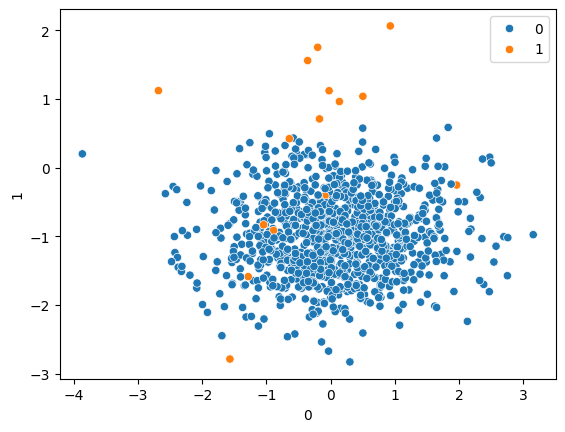

In [56]:
#visualization

sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1], hue=y)


In [57]:
#splitting data into train and test datasets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [59]:
#grid param for hyperparameter tuning

solver = ['sag', 'saga', 'liblinear', 'lbfgs']
l1_ratio = [0, 1, 0.5, 0.8]
c_values = [1, 10, 0.1, 0.01]
class_weight = [{0:w, 1:wo} for w in [1, 10, 50, 100] for wo in [1, 10, 50, 100]]

In [60]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [61]:
cv = StratifiedKFold(n_splits=4)
logistic_regressor = LogisticRegression()
params = dict(l1_ratio=l1_ratio, C=c_values, class_weight=class_weight, solver=solver)
gridcv = GridSearchCV(estimator=logistic_regressor, param_grid=params, scoring="accuracy", cv=cv)
gridcv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'l1_ratio': [0, 1, ...], 'solver': ['sag', 'saga', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [62]:
#model training

gridcv.fit(x_train, y_train)
y_pred = gridcv.predict(x_test)

d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Machine_Learning_Works\.venv\Lib\site-packages\sklearn\linear_model\_sag

In [63]:
gridcv.best_score_

np.float64(0.99625)

In [64]:
gridcv.best_params_

{'C': 0.1,
 'class_weight': {0: 10, 1: 50},
 'l1_ratio': 0,
 'solver': 'liblinear'}